In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForaging as AFtask


In [5]:
modelname = 'test'

epoch_size = 3333
n_epoch = 33
n_seed = 1
seed = 0
np.random.seed(seed)

# vary conditions
vmin, vmax = 0.1, 5
att_cost_list = np.linspace(vmin, vmax, 5)
plist = [np.array([.5, .7])]
node_list = [25]
# fixed params
# attcost = -1.6
facost = -50
env_param = [0, None, 0, .25, facost, 0, 0]

# for plotting
no_episodes = 222 # for eval plot during training
plot_no_episodes = 55 # for raster plot
minlen, maxlen=0,np.inf
nbin=15
bins=np.linspace(0,1,nbin)


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch0, node25: yctore/seed0_test_n25_p[0.5 0.7]_ep0 saved


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


total reward: 0.0


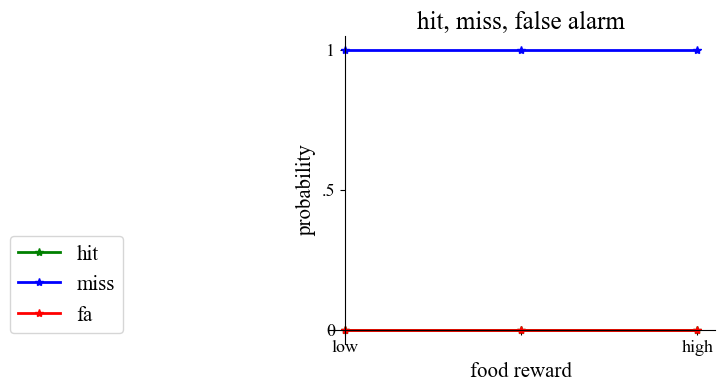

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch1, node25: yctore/seed0_test_n25_p[0.5 0.7]_ep1 saved
total reward: 0.0


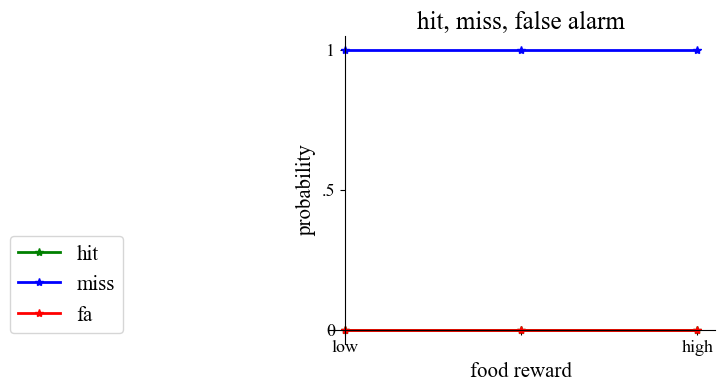

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch2, node25: yctore/seed0_test_n25_p[0.5 0.7]_ep2 saved
total reward: 0.0


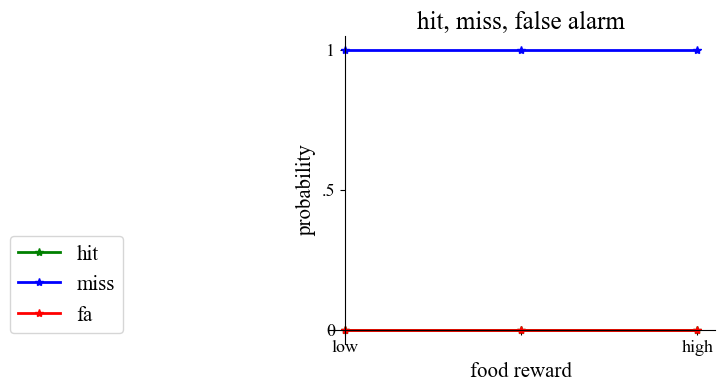

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


KeyboardInterrupt: 

In [6]:
for iepoch in range(0, n_epoch):
    # training ----------------
    for node in node_list:
        for p1p2 in plist:
            thismodel = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch}'
        
            task = AFtask(spec={'agent':
                            {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]},
                            'experiment': {'no_signal_nodes': node}})
            task.att_cost_list = att_cost_list
            task.food_reward=500
            task.food_reward_list=np.linspace(30,500,3)
            task.obs_certainity_possible = p1p2
            taskbelief = FuncBeliefModel(env=task, rng=1)


            # train
            if iepoch == 0:
                model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                            clip_range=0.1, ent_coef=0.01)
            else:
                previous_model = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch-1}'
                model = PPO.load(f'ycstore/{previous_model}', env=taskbelief)
            model.learn(total_timesteps=epoch_size,)
            model.save(f'ycstore/{thismodel}')
            print(f'epoch{iepoch}, node{node}: yctore/{thismodel} saved')
            model = PPO.load(f'ycstore/{thismodel}', env=taskbelief) # test load


            # eval block
            def eval_wrapper(a):
                episode = run_one_episode_cont(task=task, taskbelief=taskbelief, agent=model,
                                        num_steps=100000, deterministic=True)
                return episode
            

            results=[]
            with multiprocess.Pool(processes=8) as pool:
                all_episode_data = pool.map(eval_wrapper, range(no_episodes))

            for episode in all_episode_data:
                # process
                # episode['inode'] = inode
                # episode['ip'] = ip
                episode['at_times'] = np.where(
                    np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
                episode['at_seq'] = [float(elt[1])
                                    for elt in episode['actions']]
                if episode['actions'][-1][0] == 1:
                    episode['licktime'] = int(len(episode['states']))
                else:
                    episode['lick_licktimetime'] = -1
                episode['trial_len'] = len(episode['actions'])
                
                results.append(episode)

            df = pd.DataFrame(results)
            print(f'total reward: {sum(np.concatenate(df.rewards.to_numpy()))}')



            def hit_reaction_plot_cont(df):
                ''' cont action'''
                # process data
                hit_count_list = [[0] for _ in range(len(task.food_reward_list))]
                miss_count_list = [[0] for _ in range(len(task.food_reward_list))]
                false_alarm_list = [[0] for _ in range(len(task.food_reward_list))]

                noise_time_before_lick_list = [[0] for _ in range(len(task.food_reward_list))]
                signal_time_before_lick_list = [[0] for _ in range(len(task.food_reward_list))]
                total_noise_time_list = [[0] for _ in range(len(task.food_reward_list))]
                total_signal_time_list = [[0] for _ in range(len(task.food_reward_list))]
                # dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
                total_reward_dist= [[] for _ in range(len(task.food_reward_list))]
                rt_hit_dist=[[] for _ in range(len(task.food_reward_list))]
                rt_fa_dist=[[] for _ in range(len(task.food_reward_list))]
                total_att_time_dist = [[] for _ in range(len(task.food_reward_list))]

                for i in range(len(df)):
                    (food_reward_idx,
                    hit_count,
                    miss_count,
                    false_alarm_count,

                    noise_time_before_lick,
                    signal_time_before_lick,
                    total_noise_time,
                    total_signal_time,

                    total_reward,

                    attention_time_points_across_episodes,
                    episode_length_across_episodes,
                    hit_reaction_time_across_episodes,
                    fa_reaction_time_across_episodes
                    ) = process_one_subdf_df(df.iloc[i])

                    hit_count_list[food_reward_idx][0] += (hit_count)
                    miss_count_list[food_reward_idx][0] += (miss_count)
                    false_alarm_list[food_reward_idx][0] += (false_alarm_count)

                    noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
                    signal_time_before_lick_list[food_reward_idx][0] += (
                        signal_time_before_lick)
                    total_noise_time_list[food_reward_idx][0] += (total_noise_time)
                    total_signal_time_list[food_reward_idx][0] += (total_signal_time)

                    total_reward_dist[food_reward_idx].append(total_reward)
                    rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
                    rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
                    total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))


                # 3 curve plot
                hit_count_list, miss_count_list, false_alarm_list = np.array(
                    hit_count_list), np.array(miss_count_list), np.array(false_alarm_list)
                hit_prob = [hit_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                                false_alarm_list[i]) for i in range(len(hit_count_list))]
                miss_prob = [miss_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                                    false_alarm_list[i]) for i in range(len(hit_count_list))]
                fa_prob = [false_alarm_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                                false_alarm_list[i]) for i in range(len(hit_count_list))]

                xs=np.arange(len(task.food_reward_list))
                fig, ax=plt.subplots(1,1, figsize=(5,4))

                ax.plot(xs, hit_prob, '-*g', label='hit')
                ax.plot(xs, miss_prob, '-*b', label='miss')
                ax.plot(xs, fa_prob, '-*r', label='fa')
                quickleg(ax, bbox_to_anchor=(-0.5,0))
                ax.set_xlabel('food reward')
                ax.set_ylabel('probability')
                # ax.set_xticks(xs, [f'{a:.0f}' for a in task.food_reward_list]) # actual values
                ax.set_xticks([xs[i] for i in [0,-1]], ['low', 'high']) # low high
                ax.set_xticks(xs)
                ax.set_yticks([0,0.5,1], ['0', '.5','1'])
                ax.set_xticks(xs)
                centerax(ax)
                ax.set_title('hit, miss, false alarm')
                plt.show()

            hit_reaction_plot_cont(df)

In [ ]:
df.iloc[0]

food_reward_idx                                                      1
num_steps                                                           88
actions              [[0.0, 0.076128736], [0.0, -0.012825892], [0.0...
rewards              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
states               [[27], [0], [0], [0], [0], [0], [0], [0], [0],...
observations         [[100.0], [-9.990979014207195], [-9.9985382613...
beliefs              [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
p1p2                                                        [0.5, 0.7]
q_states             [[0], [1], [2], [3], [4], [5], [6], [7], [8], ...
q_probs              [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
at_times                                                            []
at_seq               [0.07612873613834381, -0.012825892306864262, -...
lick_licktimetime                                                   -1
trial_len                                                           88
Name: 

In [ ]:

    # # eval collection --------------------
    # results=[]
    # for inode, node in enumerate(node_list):
    #     for ip, p1p2 in enumerate(plist):
    #         task = AFtask(spec={'agent': 
    #                                     {'lick_cost': env_param[0],
    #                                     'food_reward': env_param[1],
    #                                     'attention_cost_coeff': env_param[2],
    #                                     'attention_cost_temp': env_param[3],
    #                                     'penalty_cost': env_param[4],
    #                                     'iti_cost': env_param[5],
    #                                     'time_in_game_reward': env_param[6]},
    #                                     'experiment':{                              'no_signal_nodes':node}})
    #         task.task.food_reward_list = task.food_reward_list
    #         taskbelief = FuncBeliefModel(env=task, rng=1)
    #         task.obs_certainity_possible = p1p2
    #         thismodel = f'seed{seed}_{modelname}_n{node}_p{p1p2}_ep{iepoch}'
    #         model = PPO.load(f'ycstore/{thismodel}')

    #         def eval_wrapper(a):
    #             episode = run_one_episode_attcost(task=task, taskbelief=taskbelief, agent=model,
    #                                     num_steps=100000, deterministic=True)
    #             return episode

    #         with multiprocess.Pool(processes=8) as pool:
    #             all_episode_data = pool.map(eval_wrapper, range(no_episodes))
            
    #         for episode in all_episode_data:
    #             # process
    #             episode['inode'] = inode
    #             episode['ip'] = ip
    #             episode['at_times'] = np.where(
    #                 np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
    #             episode['at_seq'] = [float(elt[1])
    #                                 for elt in episode['actions']]
    #             if episode['actions'][-1][0] == 1:
    #                 episode['licktime'] = int(len(episode['states']))
    #             else:
    #                 episode['lick_licktimetime'] = -1
    #             episode['trial_len'] = len(episode['actions'])
                
    #             results.append(episode)

    # df = pd.DataFrame(results)
    # print(f'total reward: {sum(np.concatenate(df.rewards.to_numpy()))}')
    # hit_reaction_plot(df)

